In [1]:
import pandas as pd

In [2]:
dataset = {
    "Study Hours": [2,5,8,3,7,1,6,4,9,2,5,6,1,3,8,7,4,9,10,2],
    "Attendance": [60,80,90,70,85,50,78,65,95,55,76,88,40,60,92,84,66,97,99,53],
    "PastScore": [40,60,75,50,70,30,68,55,80,35,65,72,25,45,78,69,58,85,90,32],
    "Internet": ["Yes", "No", "Yes", "Yes", "No", "No", "Yes", "No", "Yes", "No", "Yes", "Yes", "No", "No", "Yes", "Yes", "No", "Yes", "Yes", "No"],
    "SleepHours": [5,6,8,5,7,4,6,5,9,4,6,7,3,4,8,7,5,9,10,3],
    "Passed": ["No", "Yes", "Yes", "No", "Yes", "No", "Yes", "No", "Yes", "No", "Yes", "Yes", "No", "No", "Yes", "Yes", "No", "Yes", "Yes", "No"]
}

df = pd.DataFrame(dataset)

In [3]:
Student_data = df.to_csv("Student_data.csv", index=False)

In [4]:
student = pd.read_csv("Student_data.csv")
student.head()

,Study Hours,Attendance,PastScore,Internet,SleepHours,Passed
0,2,60,40,Yes,5,No
1,5,80,60,No,6,Yes
2,8,90,75,Yes,8,Yes
3,3,70,50,Yes,5,No
4,7,85,70,No,7,Yes


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [6]:
student.shape

(20, 6)

In [7]:
student.columns

Index(['Study Hours', 'Attendance', 'PastScore', 'Internet', 'SleepHours',
       'Passed'],
      dtype='object')

In [8]:
student.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Study Hours  20 non-null     int64 
 1   Attendance   20 non-null     int64 
 2   PastScore    20 non-null     int64 
 3   Internet     20 non-null     object
 4   SleepHours   20 non-null     int64 
 5   Passed       20 non-null     object
dtypes: int64(4), object(2)
memory usage: 1.1+ KB


In [9]:
student.describe()

,Study Hours,Attendance,PastScore,SleepHours
count,20.000000,20.000000,20.00000,20.000000
mean,5.100000,74.150000,59.10000,6.050000
std,2.845125,17.372922,19.41215,2.038446
min,1.000000,40.000000,25.00000,3.000000
25%,2.750000,60.000000,43.75000,4.750000
50%,5.000000,77.000000,62.50000,6.000000
75%,7.250000,88.500000,72.75000,7.250000
max,10.000000,99.000000,90.00000,10.000000


In [10]:
student.isnull().sum()

Study Hours    0
Attendance     0
PastScore      0
Internet       0
SleepHours     0
Passed         0
dtype: int64

In [11]:
student.duplicated().sum()

np.int64(0)

<Axes: >

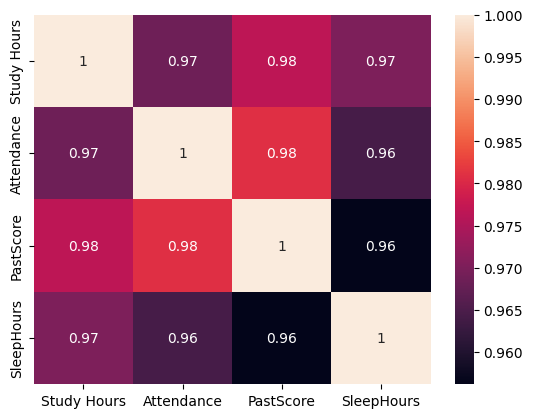

In [12]:
sns.heatmap(student.corr(numeric_only=True), annot=True)

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

student["Internet"] = le.fit_transform(student["Internet"])
student["Passed"] = le.fit_transform(student["Passed"])

In [14]:
student.head()

,Study Hours,Attendance,PastScore,Internet,SleepHours,Passed
0,2,60,40,1,5,0
1,5,80,60,0,6,1
2,8,90,75,1,8,1
3,3,70,50,1,5,0
4,7,85,70,0,7,1


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

student_copy = student.copy()

features = student_copy.drop("Passed", axis=1)

student_copy[features.columns] = scaler.fit_transform(features)


In [16]:
X = student_copy.drop("Passed", axis=1)
y = student_copy["Passed"]

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y , test_size= 0.3, random_state=42)

from sklearn.linear_model import LogisticRegression

lg_model = LogisticRegression()

lg_model.fit(X_train, y_train)
y_pred = lg_model.predict(X_test)

In [18]:
from sklearn.metrics import confusion_matrix, classification_report

cls_report = classification_report(y_test, y_pred)
cnf_matrix = confusion_matrix(y_test, y_pred)

In [19]:
cnf_matrix

array([[2, 0],
       [1, 3]])

In [20]:
print(cls_report)

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.75      0.86         4

    accuracy                           0.83         6
   macro avg       0.83      0.88      0.83         6
weighted avg       0.89      0.83      0.84         6



In [30]:
try:
    study_hours = float(input("Enter Study Hours: "))
    attendance = float(input("Enter Attendance: "))
    past_score = float(input("Enter Past Score: "))
    internet = input("Are using internet(Yes or No): ")
    sleep_hours = float(input("Enter Sleep Hours: "))

except ValueError:
    print("Invalid input. Please enter numbers only.")

new_student = pd.DataFrame({
    'Study Hours': [study_hours],
    'Attendance': [attendance],
    'PastScore': [past_score],
    "Internet": [internet],
    'SleepHours': [sleep_hours]
})
new_student['Internet'] = le.fit_transform(new_student["Internet"])
new_student_scaled = scaler.transform(new_student)
prediction = lg_model.predict(new_student_scaled)

result = "pass" if prediction[0] == 1 else "Fail"
print(f"According submitted data base you have to be {result}")

Enter Study Hours:  2
Enter Attendance:  60
Enter Past Score:  40
Are using internet(Yes or No):  Yes
Enter Sleep Hours:  5


According submitted data base you have to be Fail


C:\Users\manor\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [23]:
student.head()

,Study Hours,Attendance,PastScore,Internet,SleepHours,Passed
0,2,60,40,1,5,0
1,5,80,60,0,6,1
2,8,90,75,1,8,1
3,3,70,50,1,5,0
4,7,85,70,0,7,1


In [31]:
import joblib
joblib.dump(lg_model, "Student_score.pkl")

['Student_score.pkl']

In [32]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']